### 04 -- A/B COMPARISON -- DEMOGRAPHICS VARIABLES -- MATHS CHECK 

In [8]:
# 1. Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('client_kpi_table.csv')

In [9]:
# 2. Define Bins for Demographic & Behavior variables for Dashboard
# Numerical columns only for now

# Client tenure and age are obviously correlated, they can be regrouped later if needed  
demographic_vars = ['clnt_age', 'bal'] # handle gender separately later (CATEGORICAL)
behavior_vars = ['clnt_tenure_mnth', 'num_accts', 'calls_6_mnth', 'logons_6_mnth']

all_metrics = (demographic_vars + behavior_vars)

# all_metrics

In [10]:
# 3. Create summary_stats Table 
# Get Mean, Median, and Std Dev for main metrics by VARIATION A/B -- Flip R & C with .T (Transpose)
# Double check against all our 03 & 04 Notebooks TODO

summary_stats = df.groupby('Variation')[all_metrics].agg(['count', 'mean', 'median', 'std']).T

summary_stats.head(24)


Variation                      Control           Test
clnt_age         count    23526.000000   26961.000000
                 mean        47.498427      47.163922
                 median      48.500000      47.500000
                 std         15.521781      15.514461
bal              count    23526.000000   26961.000000
                 mean    150151.900186  148962.605032
                 median   66031.450000   65468.360000
                 std     295812.405529  307373.713775
clnt_tenure_mnth count    23526.000000   26961.000000
                 mean       151.062102     149.852899
                 median     137.000000     134.000000
                 std         82.127663      81.783390
num_accts        count    23526.000000   26961.000000
                 mean         2.259925       2.249917
                 median       2.000000       2.000000
                 std          0.538568       0.529335
calls_6_mnth     count    23526.000000   26961.000000
                 mean         3.129176       3.061941
                 median       3.000000       3.000000
                 std          2.184541       2.190590
logons_6_mnth    count    23526.000000   26961.000000
                 mean         6.166242       6.101851
                 median       6.000000       6.000000
                 std          2.173053       2.177119

### CSV EXPORT SUMMARY_STATS 

In [11]:
# 4. Save Num. Demo Stats to CSV -- Export May 06

# summary_stats.to_csv('ab_summary_stats.csv')

# Sanity checks -- see new nb 04- TODO 

# df["Variation"].value_counts()
# df["Variation"].value_counts(normalize=True) * 100
# etc. see scratchpad
gendr
U    17282
M    16947
F    16258
Name: count, dtype: int64
Variation
Test       26961
Control    23526
Name: count, dtype: int64
Variation
Test       53.401866
Control    46.598134
Name: proportion, dtype: float64

## TOTAL DEMOGRAPHICS FROM 04_demographics_kpi_eda.ipynb -- COMPARE WITH MY SPLIT A/B METRIC IF NUMS MAKE SENSE TODO

        clnt_age 	clnt_tenure_mnth num_accts 	bal 	calls_6_mnth 	logons_6_mnth
count 	50487.0000      50487.0000 	50487.0000  5.048700e+04 	50487.0000 	50487.000000
mean 	47.319795 	150.416365 	2.254580 	1.495168e+05 	3.093272 	6.131856
std 	15.518616 	81.945403 	0.533675 	3.020390e+05 	2.188009 	2.175441
min 	17.000000 	33.000000 	1.000000 	2.378944e+04 	0.000000 	3.000000
25% 	33.500000 	82.000000 	2.000000 	3.987718e+04 	1.000000 	4.000000
50% 	48.000000 	136.000000 	2.000000 	6.573433e+04 	3.000000 	6.000000
75% 	59.500000 	192.000000 	2.000000 	1.399583e+05 	5.000000 	8.000000
max 	96.000000 	669.000000 	7.000000 	1.632004e+07 	6.000000 	9.000000

## DATAVIZ AGE BINS see 04_demographics_kpi_eda.ipynb TODO


## A/B Visuals -- Control vs. Test Variation -- Demo Data

In [12]:
# Use sns.kdeplot (Density/Peaks) or sns.boxplot for Num. variables

# Set colour palette -- Control = Blue, Test = Orange/Yellow -- CHANGE COLOUR/LOOK TODO

palette = {'Control': '#1f77b4', 'Test': '#ff7f0e'}
sns.set_style("whitegrid")

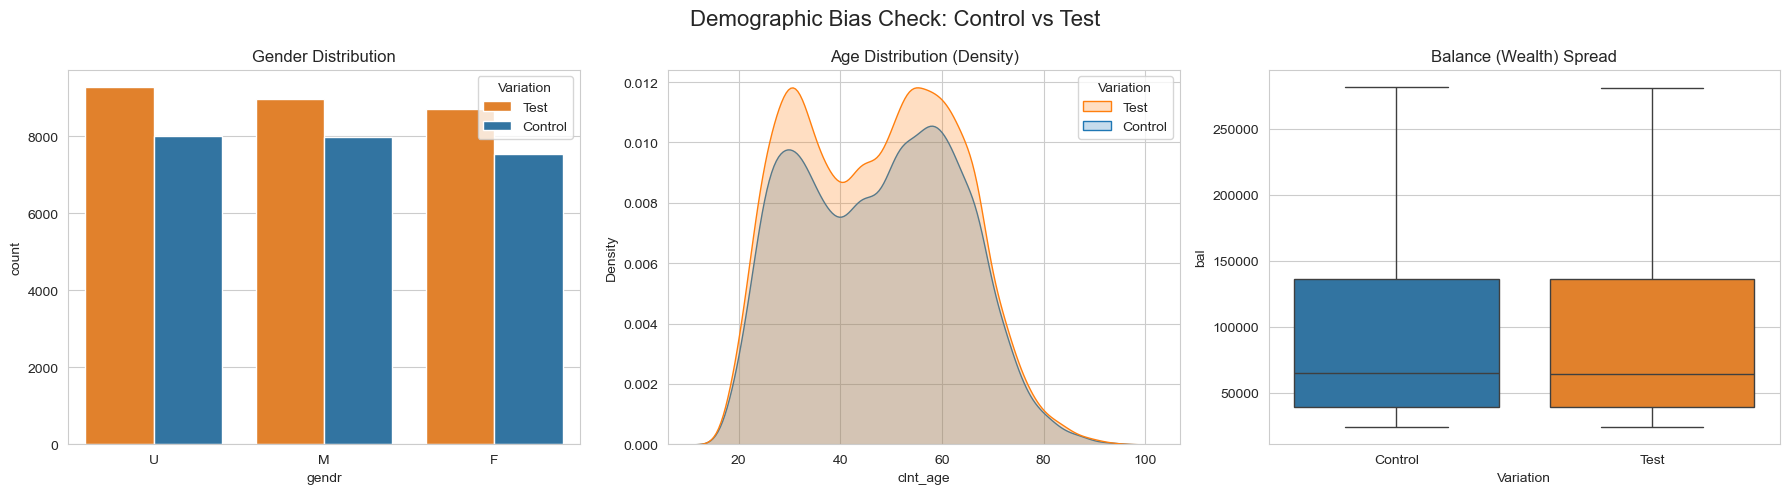

In [13]:
# --- 1. DEMOGRAPHICS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Demographic Bias Check: Control vs Test', fontsize=16)

# Gender (Categorical)
# use sns.barplot for Categorical gender col 
sns.countplot(data=df, x='gendr', hue='Variation', palette=palette, ax=axes[0])
axes[0].set_title('Gender Distribution')

# Age (Numerical)
sns.kdeplot(data=df, x='clnt_age', hue='Variation', palette=palette, fill=True, ax=axes[1])
axes[1].set_title('Age Distribution (Density)')

# Balance (Numerical -- check for Null and skew, use boxplots)
# Double check percentage of zero balances
zero_bal_pct = (df['bal'] == 0).mean() * 100 # print(f"Percentage of participants with 0 balance: {zero_bal_pct:.2f}%")
plot_data = df[df['bal'] > 0].dropna() # Drop missing for Barplot

sns.boxplot(data=plot_data, x='Variation', y='bal', hue='Variation', 
            palette=palette, ax=axes[2], legend=False, showfliers=False) # Hide outlier dots

axes[2].set_title('Balance (Wealth) Spread')

plt.tight_layout()
plt.show()


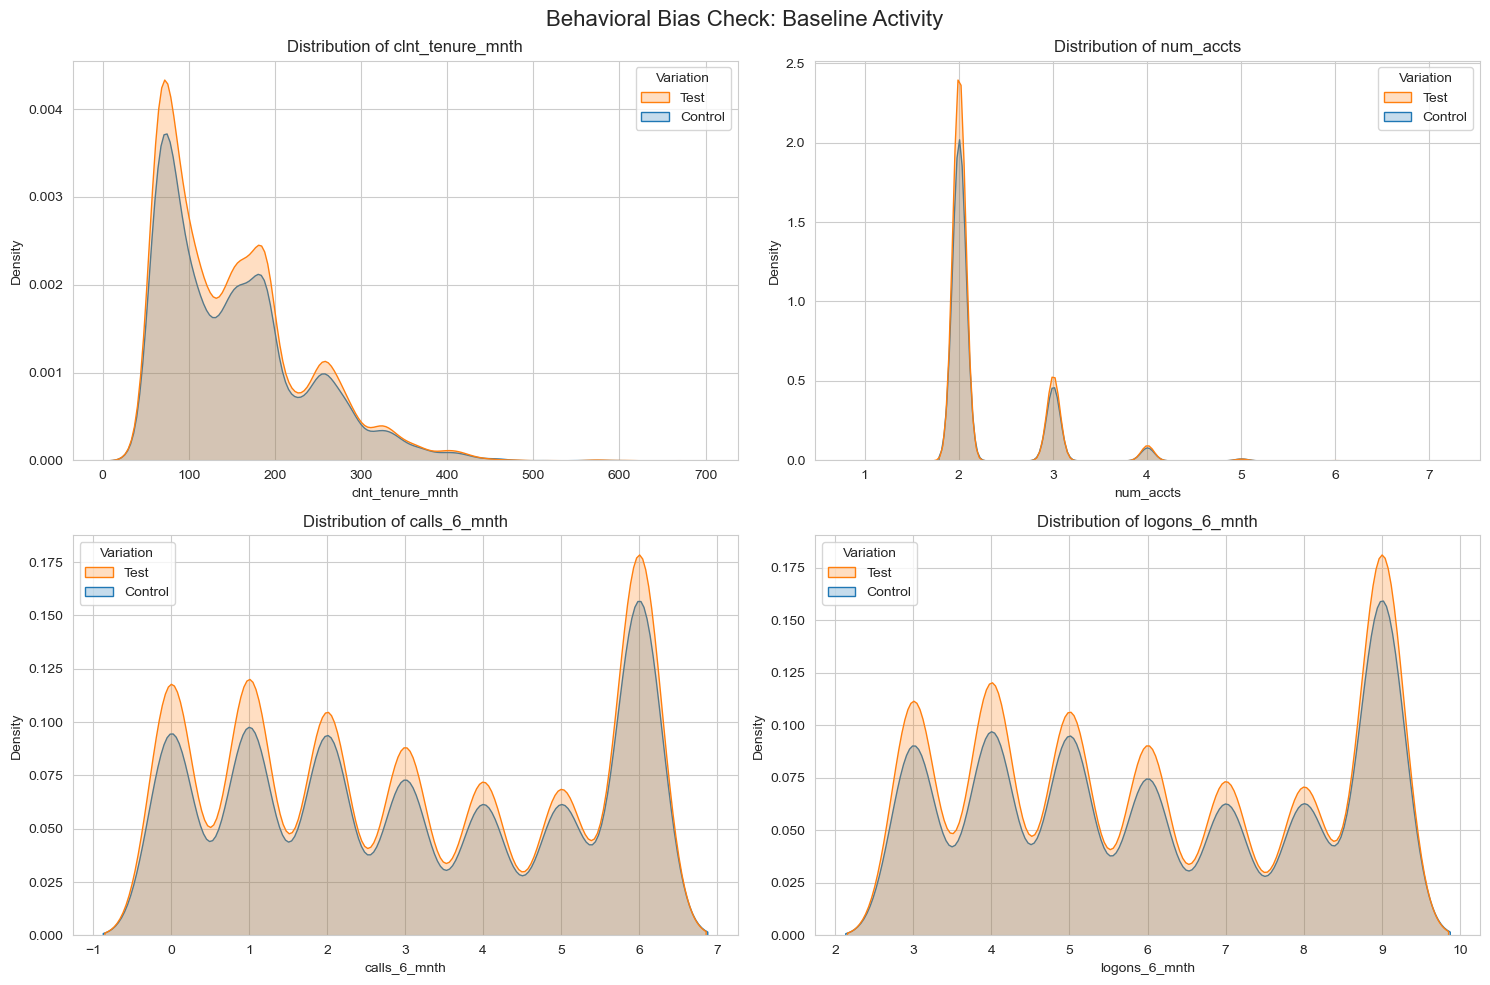

In [14]:
# --- 2. USER BEHAVIOUR ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Behavioral Bias Check: Baseline Activity', fontsize=16)

# Flatten axis 
behav_axes = axes.flatten()

for i, var in enumerate(behavior_vars):
    sns.kdeplot(data=df, x=var, hue='Variation', palette=palette, fill=True, ax=behav_axes[i])
    behav_axes[i].set_title(f'Distribution of {var}')

plt.tight_layout()
plt.show()


### TODO 
- look at st.deviation in all metrics 
- compare TOTAL metrics from 04_demographics_kpi_eda.ipynb with my summary_stats

- remaining stats and KPI maths tests for Client Data - Session/Completion Variables  